In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [2]:
train_df = pd.read_stata("wage1(1).dta")
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 526 entries, 0 to 525
Data columns (total 24 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   wage      526 non-null    float32
 1   educ      526 non-null    int8   
 2   exper     526 non-null    int8   
 3   tenure    526 non-null    int8   
 4   nonwhite  526 non-null    int8   
 5   female    526 non-null    int8   
 6   married   526 non-null    int8   
 7   numdep    526 non-null    int8   
 8   smsa      526 non-null    int8   
 9   northcen  526 non-null    int8   
 10  south     526 non-null    int8   
 11  west      526 non-null    int8   
 12  construc  526 non-null    int8   
 13  ndurman   526 non-null    int8   
 14  trcommpu  526 non-null    int8   
 15  trade     526 non-null    int8   
 16  services  526 non-null    int8   
 17  profserv  526 non-null    int8   
 18  profocc   526 non-null    int8   
 19  clerocc   526 non-null    int8   
 20  servocc   526 non-null    int8  

In [3]:
train_df.head()

,wage,educ,exper,tenure,nonwhite,female,married,numdep,smsa,northcen,...,trcommpu,trade,services,profserv,profocc,clerocc,servocc,lwage,expersq,tenursq
0,3.10,11,2,0,0,1,0,2,1,0,...,0,0,0,0,0,0,0,1.131402,4,0
1,3.24,12,22,2,0,1,1,3,1,0,...,0,0,1,0,0,0,1,1.175573,484,4
2,3.00,11,2,0,0,0,0,2,0,0,...,0,1,0,0,0,0,0,1.098612,4,0
3,6.00,8,44,28,0,0,1,0,1,0,...,0,0,0,0,0,1,0,1.791759,1936,784
4,5.30,12,7,2,0,0,1,1,0,0,...,0,0,0,0,0,0,0,1.667707,49,4


In [4]:
train_df.describe()

,wage,educ,exper,tenure,nonwhite,female,married,numdep,smsa,northcen,...,trcommpu,trade,services,profserv,profocc,clerocc,servocc,lwage,expersq,tenursq
count,526.000000,526.000000,526.00000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,...,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000
mean,5.896103,12.562738,17.01711,5.104563,0.102662,0.479087,0.608365,1.043726,0.722433,0.250951,...,0.043726,0.287072,0.100760,0.258555,0.366920,0.167300,0.140684,1.623268,473.435361,78.150190
std,3.693085,2.769022,13.57216,7.224462,0.303805,0.500038,0.488580,1.261891,0.448225,0.433973,...,0.204680,0.452826,0.301298,0.438257,0.482423,0.373599,0.348027,0.531538,616.044772,199.434664
min,0.530000,0.000000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.634878,1.000000,0.000000
25%,3.330000,12.000000,5.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.202972,25.000000,0.000000
50%,4.650000,12.000000,13.50000,2.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.536867,182.500000,4.000000
75%,6.880000,14.000000,26.00000,7.000000,0.000000,1.000000,1.000000,2.000000,1.000000,0.750000,...,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.928619,676.000000,49.000000
max,24.980000,18.000000,51.00000,44.000000,1.000000,1.000000,1.000000,6.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.218076,2601.000000,1936.000000


In [5]:
X = train_df.drop(columns=['wage', 'lwage'])
y = train_df['wage']

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42)

# train and dev 
X_train, X_dev, y_train, y_dev = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42)

print(f"Train: {X_train.shape}")
print(f"Dev:   {X_dev.shape}")
print(f"Test:  {X_test.shape}")

Train: (379, 22)
Dev:   (68, 22)
Test:  (79, 22)


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso

# 1. Scaling 
numeric_cols = ['educ', 'exper', 'tenure', 'numdep']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_dev_scaled = X_dev.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_dev_scaled[numeric_cols] = scaler.transform(X_dev[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])


5.8313216706544395 0.19560956304513444
0.4947433271074918
profocc     1.972298
smsa        0.675629
clerocc     0.389999
educ        0.388554
west        0.343542
tenure      0.210041
exper       0.163363
construc    0.060191
numdep      0.056945
married     0.006164
tenursq    -0.001881
expersq    -0.003430
south      -0.030749
servocc    -0.045691
nonwhite   -0.402408
northcen   -0.481225
ndurman    -0.774376
profserv   -1.089807
trcommpu   -1.359413
female     -1.483229
services   -1.933388
trade      -2.040967
dtype: float64


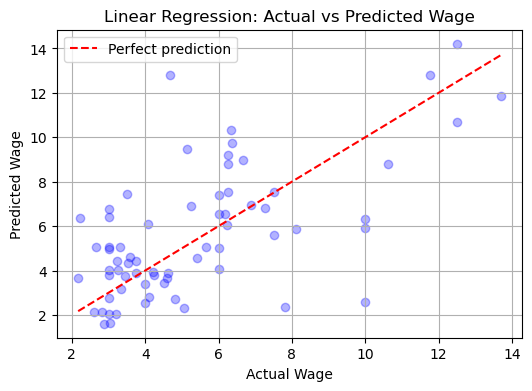

In [7]:
#linear regression 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_train_pred_lr = lr.predict(X_train)

# Train R2
train_r2_lr = r2_score(y_train, y_train_pred_lr)

y_dev_pred = lr.predict(X_dev)

mse = mean_squared_error(y_dev, y_dev_pred)
r2 = r2_score(y_dev, y_dev_pred)

print(mse, r2)
print(train_r2_lr)
coef = pd.Series(lr.coef_, index=X_train.columns)
print(coef.sort_values(ascending=False))

plt.figure(figsize=(6, 4))
plt.scatter(y_dev, y_dev_pred, alpha=0.3, color='blue')
plt.plot([y_dev.min(), y_dev.max()], [y_dev.min(), y_dev.max()], color='red', linestyle='--', label='Perfect prediction')
plt.xlabel("Actual Wage")
plt.ylabel("Predicted Wage")
plt.title("Linear Regression: Actual vs Predicted Wage")
plt.legend()
plt.grid()
plt.show()

In [8]:
#analysis
#Positive (increases wage):

#exper: +2.23 — experience has the biggest positive impact, each additional year adds $2.23/hr
#profocc: +1.97 — having a professional occupation adds $1.97/hr
#tenure: +1.42 — each year with current employer adds $1.42/hr
#educ: +1.06 — each extra year of education adds $1.06/hr
#smsa: +0.68 — living in a metropolitan area adds $0.68/hr

#Negative (decreases wage):

#female: -1.48 — being female reduces wage by $1.48/hr — this is the gender wage gap!
#trade: -2.04 — working in trade industry reduces wage by $2.04/hr
#services: -1.93 — service industry reduces wage by $1.93/hr
#nonwhite: -0.40 — racial wage gap of $0.40/hr

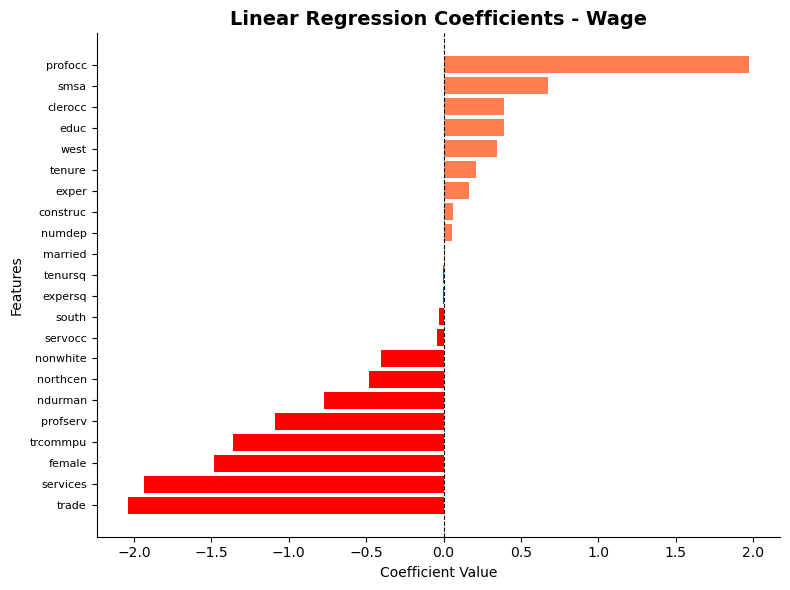

In [9]:


coef_wage = pd.Series(lr.coef_, index=X_train.columns).sort_values()

# Plot coefficients
fig, ax = plt.subplots(figsize=(8, 6), facecolor='white')

ax.set_facecolor('white')

colors = ['red' if x < 0 else 'coral' for x in coef_wage.values]

ax.barh(coef_wage.index, coef_wage.values, color=colors)
ax.axvline(0, color='black', linestyle='--', linewidth=0.8)

ax.set_title("Linear Regression Coefficients - Wage", fontsize=14, fontweight='bold')
ax.set_xlabel("Coefficient Value")
ax.set_ylabel("Features")
ax.tick_params(axis='y', labelsize=8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()



Train R2: 0.33231419284090635
Decision Tree Results:
MSE: 6.944015336628177
RMSE: 2.6351499647322116
MAE: 1.7956317233432093
R2: 0.04212117829803186


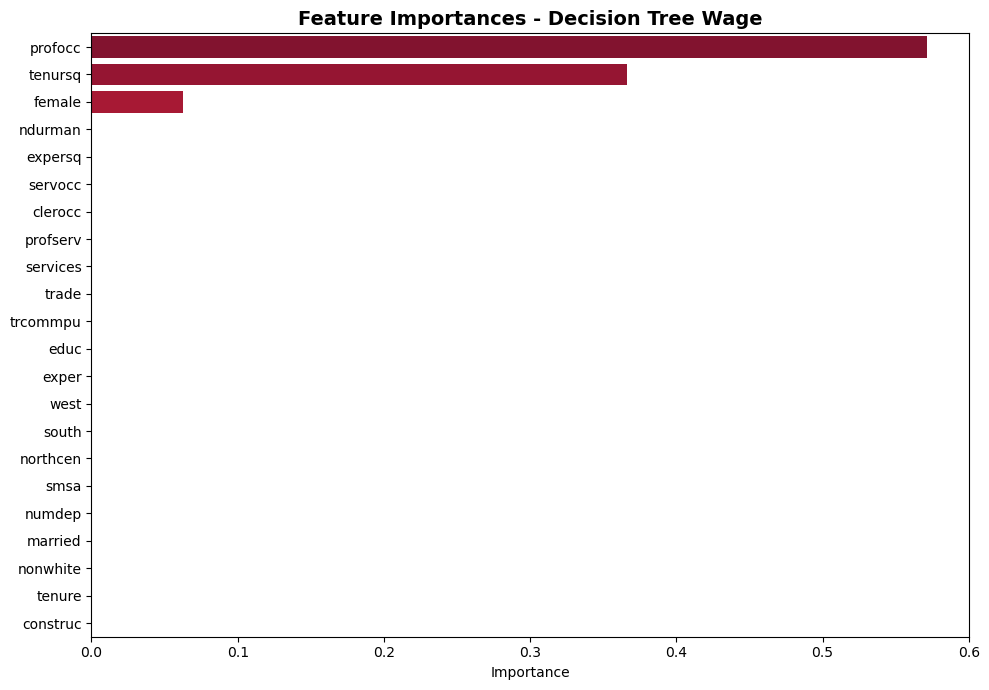

In [21]:
from sklearn.tree import DecisionTreeRegressor


dt = DecisionTreeRegressor(
    max_depth=2,
    min_samples_split=30,
    min_samples_leaf=15,
    random_state=42
)

dt.fit(X_train, y_train)

y_train_pred_dt = dt.predict(X_train)

# Train R2
train_r2 = r2_score(y_train, y_train_pred_dt)

print("Train R2:", train_r2)


y_dev_pred_dt = dt.predict(X_dev)


mse = mean_squared_error(y_dev, y_dev_pred_dt)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_dev, y_dev_pred_dt)
r2 = r2_score(y_dev, y_dev_pred_dt)

print("Decision Tree Results:")
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)



#feature importance
importances_dt_wage = pd.Series(dt.feature_importances_, index=X_train.columns)
importances_dt_wage = importances_dt_wage.sort_values(ascending=False)

plt.figure(figsize=(10, 7), facecolor='white')

sns.barplot(
    x=importances_dt_wage.values,
    y=importances_dt_wage.index,
    palette='YlOrRd_r'
)

plt.title("Feature Importances - Decision Tree Wage", fontsize=14, fontweight='bold')
plt.xlabel("Importance")
plt.ylabel("")
plt.grid(False)

plt.tight_layout()
plt.show()

6.660896899728632 2.580871345055509 1.836242931550549 0.08117540580080751


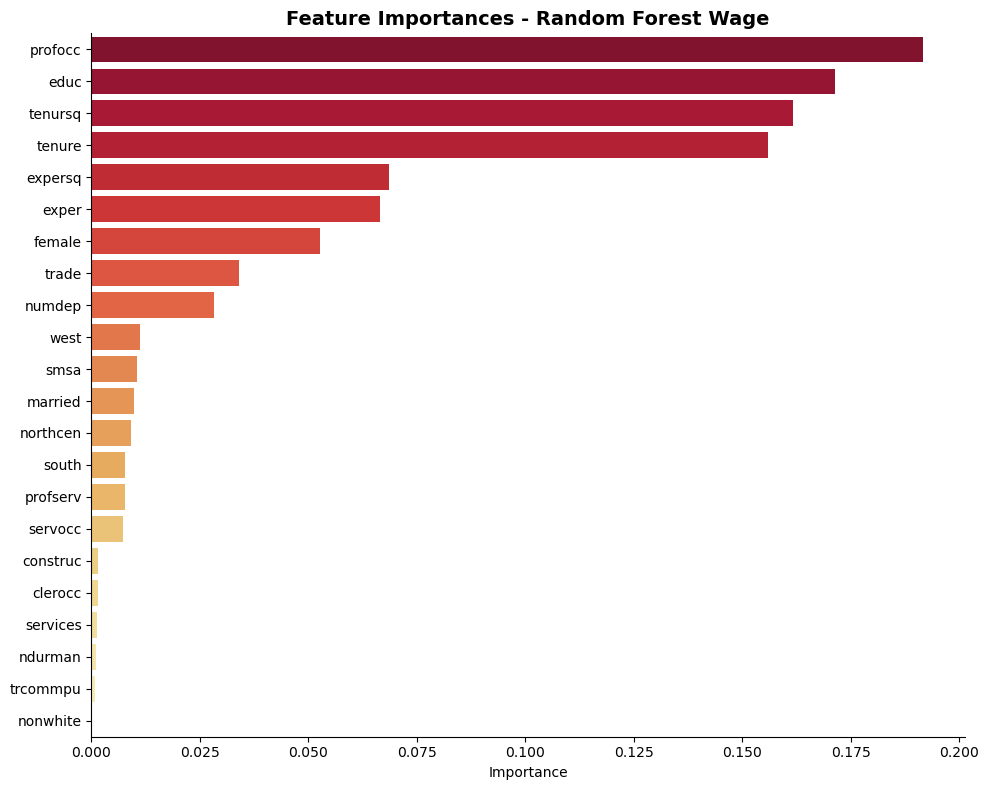

In [18]:
from sklearn.ensemble import RandomForestRegressor

rf =RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
rf.fit(X_train, y_train)


y_dev_pred_rf = rf.predict(X_dev)

mse = mean_squared_error(y_dev, y_dev_pred_rf)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_dev, y_dev_pred_rf)
r2 = r2_score(y_dev, y_dev_pred_rf)

print(mse, rmse, mae, r2)

importances_rf_wage = pd.Series(rf.feature_importances_, index=X_train.columns)
importances_rf_wage = importances_rf_wage.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8), facecolor='white')
ax.set_facecolor('white')
sns.barplot(x=importances_rf_wage.values,
            y=importances_rf_wage.index,
            palette='YlOrRd_r', ax=ax)
ax.set_title("Feature Importances - Random Forest Wage", fontsize=14, fontweight='bold')
ax.set_xlabel("Importance")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np


final_model = LinearRegression()
final_model.fit(X_train, y_train)


y_test_pred = final_model.predict(X_test)


mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print("FINAL TEST RESULTS (Linear Regression)")
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

FINAL TEST RESULTS (Linear Regression)
MSE: 6.148275852518253
RMSE: 2.479571707476566
MAE: 1.7969751513060597
R2: 0.5055062154310144
